In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import math
import matplotlib.ticker as mtick

# 1°PARTE


--- DATI ESTRATTI DAL FILE EXCEL ---
   Corrente^2 [A^2]  d.d.p [V]  Err Corrente^2 [A^2]  Err d.d.p [V]
0          0.004775     102.97              0.000014            0.1
1          0.005663     115.76              0.000015            0.1
2          0.005715     120.50              0.000015            0.1
3          0.006373     128.59              0.000016            0.1
4          0.006659     135.00              0.000016            0.1
5          0.006989     142.50              0.000017            0.1
6          0.007090     145.30              0.000017            0.1
7          0.007656     153.90              0.000018            0.1
-----------------------------------
Pendenza : (2.051 ± 0.016)e4 eV


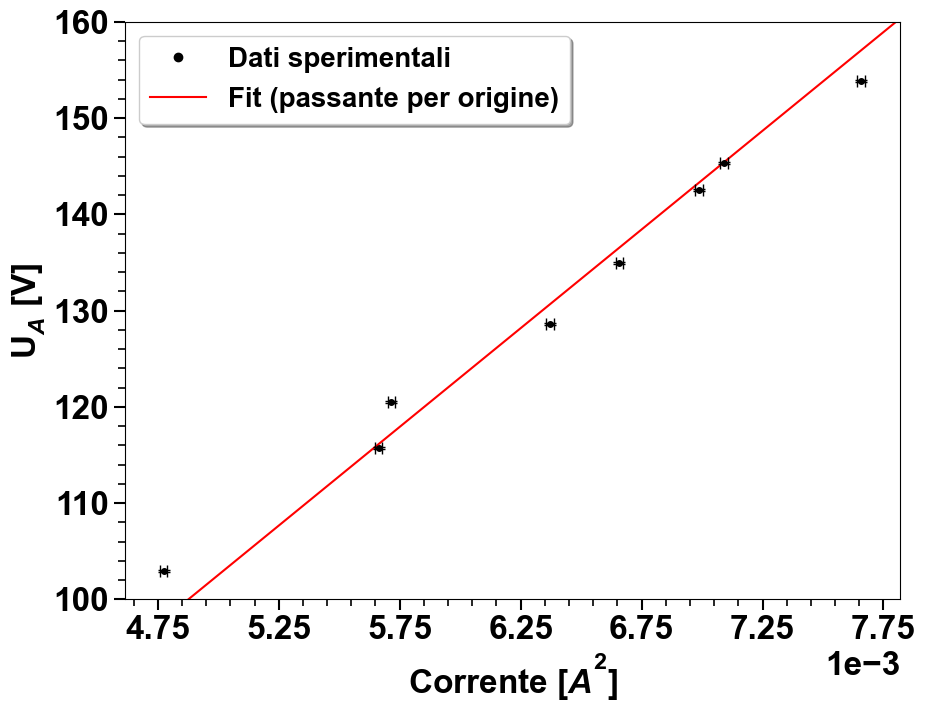

In [3]:
#--- PARTE 1: ddp vs corrente ---
file_excel = "Dualismo_Particella-Onda.xlsx"
df1 = pd.read_excel(file_excel, sheet_name=0, header=1)
    
c2 = pd.to_numeric(df1.iloc[11:19, 8]).values
ddp = pd.to_numeric(df1.iloc[11:19, 9]).values
err_c2 = pd.to_numeric(df1.iloc[11:19, 10]).values
err_ddp = pd.to_numeric(df1.iloc[11:19, 11]).values

# --- 1. NUOVO MODELLO CON Q=0 ---
def modello_origine(x, m):
    return m * x  # Non c'è più +q

# --- 2. GESTIONE ERRORI SU X E Y ---
# Per usare curve_fit con errori su X, calcoliamo un errore efficace:
# sigma_tot = sqrt(err_y^2 + (m * err_x)^2)
# Poiché non conosciamo 'm', facciamo una prima stima veloce
m_stima = np.mean(ddp / c2)
sigma_efficace = np.sqrt(err_ddp**2 + (m_stima * err_c2)**2)

# --- 3. ESECUZIONE DEL FIT ---
popt, pcov = curve_fit(modello_origine, c2, ddp, sigma=sigma_efficace, absolute_sigma=False)

slope = popt[0]
std_err = np.sqrt(pcov[0,0])

# --- NUOVA SEZIONE: STAMPA I DATI ---
print("--- DATI ESTRATTI DAL FILE EXCEL ---")
tabella_dati = pd.DataFrame({
    'Corrente^2 [A^2]': c2,
    'd.d.p [V]': ddp,
    'Err Corrente^2 [A^2]': err_c2,
    'Err d.d.p [V]': err_ddp,
})
print(tabella_dati)
print("-" * 35)

esp = math.floor(math.log10(abs(slope)))
mantenendo = 10**esp

print(f"Pendenza : ({slope/mantenendo:.3f} ± {std_err/mantenendo:.3f})e{esp} eV")


# --- CONFIGURAZIONE GRAFICO ---

# --- 1. CONFIGURAZIONE GLOBALE SANS-SERIF BOLD ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans'] # Ordine di preferenza
plt.rcParams['font.weight'] = 'bold'          # Grassetto per tutto il testo
plt.rcParams['axes.labelweight'] = 'bold'     # Grassetto per le etichette degli assi
plt.rcParams['axes.titleweight'] = 'bold'     # Grassetto per il titolo
plt.rcParams['mathtext.fontset'] = 'custom'   # Per rendere bold anche la matematica
plt.rcParams['mathtext.rm'] = 'sans'
plt.rcParams['mathtext.bf'] = 'sans:bold'

plt.figure(figsize=(10, 7.5))

# 1. Dati sperimentali (zorder=2 li mette sopra la linea)
# Non mettiamo la label qui per evitare il simbolo "sporco" in legenda
plt.errorbar(c2, ddp, xerr=err_c2, yerr=err_ddp, fmt='ko', capsize=4, zorder=2, ms=4)

# 2. Punto "pulito" solo per la legenda (trucco del punto fantasma)
plt.plot([], [], 'ko', label='Dati sperimentali')

# 3. Calcolo e disegno del Fit
# Usiamo i limiti attuali dei dati per estendere la linea di fit
x_min, x_max = plt.xlim()
x_fit = np.linspace(x_min, x_max, 100)
plt.plot(x_fit, modello_origine(x_fit, slope), 'r-', label='Fit (passante per origine)', zorder=1)

# --- GESTIONE ASSI E TICK ---
ax = plt.gca()
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax.xaxis.get_offset_text().set_fontsize(24)  # Qui decidi quanto farlo grande
ax.xaxis.get_offset_text().set_fontweight('bold') # Puoi anche farlo grassetto

# Esempio asse X: crea tick da a 
tick_x_manuali = np.arange(0.00475, 0.0078, 0.0005) 
ax.set_xticks(tick_x_manuali)

# Esempio asse Y: crea tick da 0.0 V a 2.0 V, mettendone uno ogni 0.2 V
tick_y_manuali = np.arange(100, 170, 10)
ax.set_yticks(tick_y_manuali)

# Forza la notazione scientifica (esponenziale) sull'asse X
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# Aggiungiamo i tick secondari (i trattini piccoli senza numero)
ax.xaxis.set_minor_locator(mtick.AutoMinorLocator())
ax.yaxis.set_minor_locator(mtick.AutoMinorLocator())

# --- CONFIGURAZIONE ESTETICA FINALE ---
plt.xlim(x_min, x_max)
plt.ylim(100, 160)

# Titoli e font aumentati per massima chiarezza
plt.xlabel("Corrente [$A^2$]", fontsize=24)
plt.ylabel("U$_A$ [V]", fontsize=24)



ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1.2, color='black',  labelsize=24)

# (Opzionale) Anche i tick maggiori verso fuori
ax.tick_params(axis='both', which='major', direction='out',length=8, width=1.5, color='black',  labelsize=24)


# Legenda pulita (grazie al punto fantasma di riga 11)
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=20)
# Salva il file prima di mostrarlo
plt.savefig("GRAFICI/Fit_lineare.png", dpi=300, bbox_inches='tight')
plt.show()

# 2°PARTE

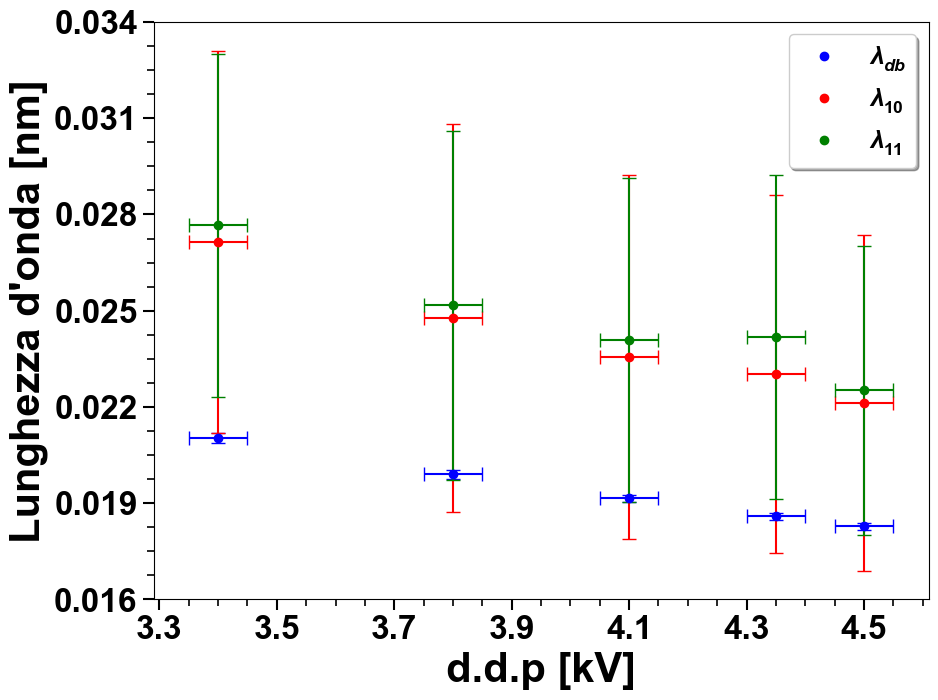

In [4]:
file_excel = "Dualismo_particella-Onda.xlsx"
df1 = pd.read_excel(file_excel, sheet_name=1, header=1)
    
# Frequenza (Asse X condiviso)
ddp= pd.to_numeric(df1.iloc[0:6, 64]).values
err_ddp= pd.to_numeric(df1.iloc[0:6, 65]).values

# --- PRIMO SET DI DATI ---
db = pd.to_numeric(df1.iloc[0:6, 66]).values
err_db = pd.to_numeric(df1.iloc[0:6, 67]).values

# --- SECONDO SET DI DATI ---
v10= pd.to_numeric(df1.iloc[0:6, 68]).values
err_v10 = pd.to_numeric(df1.iloc[0:6, 69]).values

# --- TERZOSET DI DATI ---
v11 = pd.to_numeric(df1.iloc[0:6, 70]).values
err_v11 = pd.to_numeric(df1.iloc[0:6, 71]).values


# --- GRAFICO ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans'] # Ordine di preferenza
plt.rcParams['font.weight'] = 'bold'          # Grassetto per tutto il testo
plt.rcParams['axes.labelweight'] = 'bold'     # Grassetto per le etichette degli assi
plt.rcParams['axes.titleweight'] = 'bold'     # Grassetto per il titolo
plt.rcParams['mathtext.fontset'] = 'custom'   # Per rendere bold anche la matematica
plt.rcParams['mathtext.rm'] = 'sans'
plt.rcParams['mathtext.bf'] = 'sans:bold'

plt.figure(figsize=(10, 7.5))

# Plottiamo i punti sperimentali del Set 1 (Pallini Rossi)
plt.errorbar(ddp, db, xerr=err_ddp , yerr=err_db, fmt='bo',capsize=5,)

plt.errorbar(ddp, v10, xerr=err_ddp , yerr=err_v10, fmt='ro', capsize=5,)

plt.errorbar(ddp, v11, xerr=err_ddp , yerr=err_v11, fmt='go', capsize=5)

# 2. Punto "pulito" solo per la legenda (trucco del punto fantasma)
plt.plot([], [], 'bo',label=r'$\lambda_{db}$')
plt.plot([], [], 'ro', label=r'$\lambda_{10}$')
plt.plot([], [], 'go', label=r'$\lambda_{11}$')

# --- GESTIONE ASSI E TICK ---
ax = plt.gca()
# Esempio asse X: crea tick da a 
tick_x_manuali = np.arange(3.3, 4.6, 0.2) 
ax.set_xticks(tick_x_manuali)

# Esempio asse Y: crea tick da 0.0 V a 2.0 V, mettendone uno ogni 0.2 V
tick_y_manuali = np.arange(0.016, 0.036, 0.003)
ax.set_yticks(tick_y_manuali)

# Aggiungiamo i tick secondari (i trattini piccoli senza numero)
ax.xaxis.set_minor_locator(mtick.AutoMinorLocator())
ax.yaxis.set_minor_locator(mtick.AutoMinorLocator())

ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1.2, color='black',  labelsize=24)

# (Opzionale) Anche i tick maggiori verso fuori
ax.tick_params(axis='both', which='major', direction='out',length=8, width=1.5, color='black',  labelsize=24)

plt.xlabel("d.d.p [kV]",fontsize=30) # <--- Ricorda di aggiornare l'etichetta
plt.ylabel("Lunghezza d'onda [nm]",fontsize=30)
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=18)
plt.savefig("GRAFICI/confronto_lambda.png", dpi=300, bbox_inches='tight')
plt.show()

# prova con q

--- RISULTATI DEL FIT ---
Pendenza (h/e): (18056.142 ± 679.323)e4 eV
Intercetta (W/e): 15.640 ± 4.364 eV


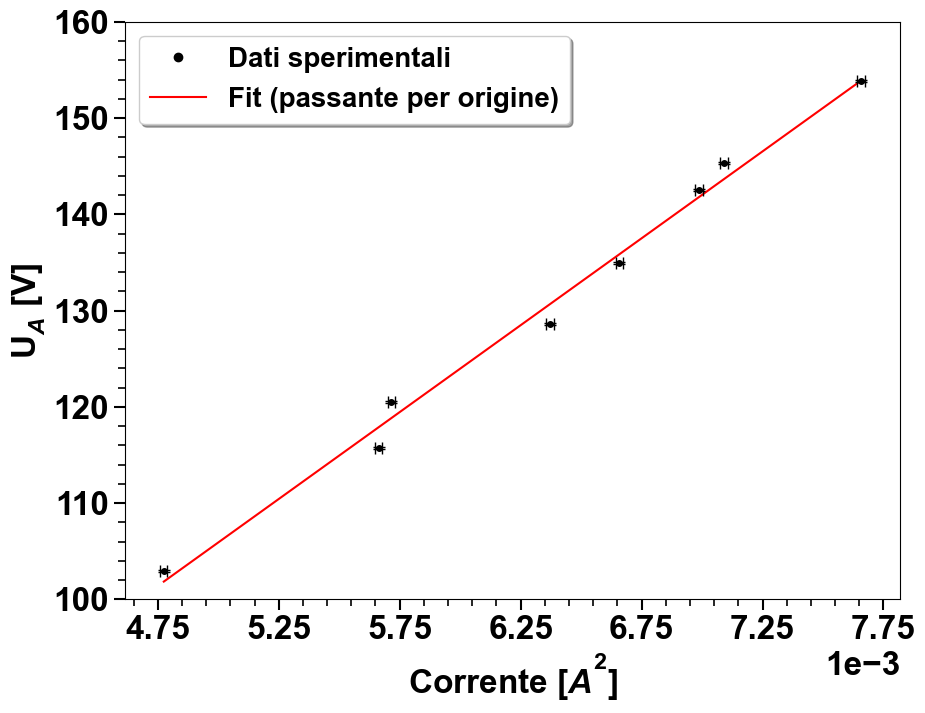

In [20]:
#--- PARTE 1: ddp vs corrente ---
file_excel = "Dualismo_Particella-Onda.xlsx"
df1 = pd.read_excel(file_excel, sheet_name=0, header=1)
    
c2 = pd.to_numeric(df1.iloc[11:19, 8]).values
ddp = pd.to_numeric(df1.iloc[11:19, 9]).values
err_c2 = pd.to_numeric(df1.iloc[11:19, 10]).values
err_ddp = pd.to_numeric(df1.iloc[11:19, 11]).values

# NOTA: Assicurati che c2, ddp, err_c2 ed err_ddp siano definiti come array NumPy
# prima di eseguire questo blocco. Ad esempio: c2 = np.array([...])

# --- 1. MODELLO LINEARE COMPLETO CON Q ---
def modello_lineare(x, m, q):
    return m * x + q

# --- ESECUZIONE DEL FIT ---
# sigma=err_v indica a scipy di pesare i punti in base all'errore sperimentale
# absolute_sigma=True assicura che la matrice di covarianza rifletta le incertezze fornite
popt, pcov = curve_fit(modello_lineare, c2, ddp, sigma=err_ddp, absolute_sigma=False)

# Estrazione parametri
slope, intercept = popt

# Calcolo errori (radice della diagonale della matrice di covarianza)
perr = np.sqrt(np.diag(pcov))
std_err = perr[0]
std_err_intercept = perr[1]

print("--- RISULTATI DEL FIT ---")
print(f"Pendenza (h/e): ({slope:.3f} ± {std_err:.3f})e{esp} eV")
print(f"Intercetta (W/e): {intercept:.3f} ± {std_err_intercept:.3f} eV")
# --- CONFIGURAZIONE GRAFICO ---

# --- 1. CONFIGURAZIONE GLOBALE SANS-SERIF BOLD ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans'] # Ordine di preferenza
plt.rcParams['font.weight'] = 'bold'          # Grassetto per tutto il testo
plt.rcParams['axes.labelweight'] = 'bold'     # Grassetto per le etichette degli assi
plt.rcParams['axes.titleweight'] = 'bold'     # Grassetto per il titolo
plt.rcParams['mathtext.fontset'] = 'custom'   # Per rendere bold anche la matematica
plt.rcParams['mathtext.rm'] = 'sans'
plt.rcParams['mathtext.bf'] = 'sans:bold'

plt.figure(figsize=(10, 7.5))

# 1. Dati sperimentali (zorder=2 li mette sopra la linea)
# Non mettiamo la label qui per evitare il simbolo "sporco" in legenda
plt.errorbar(c2, ddp, xerr=err_c2, yerr=err_ddp, fmt='ko', capsize=4, zorder=2, ms=4)

# 2. Punto "pulito" solo per la legenda (trucco del punto fantasma)
plt.plot([], [], 'ko', label='Dati sperimentali')

# 3. Calcolo e disegno del Fit
# Usiamo i limiti attuali dei dati per estendere la linea di fit
x_min, x_max = plt.xlim()
x_fit = np.linspace(x_min, x_max, 100)
plt.plot(c2, modello_lineare( c2, popt[0], popt[1]), 'r-', label='Fit (passante per origine)', zorder=1)

# --- GESTIONE ASSI E TICK ---
ax = plt.gca()
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax.xaxis.get_offset_text().set_fontsize(24)  # Qui decidi quanto farlo grande
ax.xaxis.get_offset_text().set_fontweight('bold') # Puoi anche farlo grassetto

# Esempio asse X: crea tick da a 
tick_x_manuali = np.arange(0.00475, 0.0078, 0.0005) 
ax.set_xticks(tick_x_manuali)

# Esempio asse Y: crea tick da 0.0 V a 2.0 V, mettendone uno ogni 0.2 V
tick_y_manuali = np.arange(100, 170, 10)
ax.set_yticks(tick_y_manuali)

# Forza la notazione scientifica (esponenziale) sull'asse X
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

# Aggiungiamo i tick secondari (i trattini piccoli senza numero)
ax.xaxis.set_minor_locator(mtick.AutoMinorLocator())
ax.yaxis.set_minor_locator(mtick.AutoMinorLocator())

# --- CONFIGURAZIONE ESTETICA FINALE ---
plt.xlim(x_min, x_max)
plt.ylim(100, 160)

# Titoli e font aumentati per massima chiarezza
plt.xlabel("Corrente [$A^2$]", fontsize=24)
plt.ylabel("U$_A$ [V]", fontsize=24)



ax.tick_params(axis='both', which='minor', direction='out', length=5, width=1.2, color='black',  labelsize=24)

# (Opzionale) Anche i tick maggiori verso fuori
ax.tick_params(axis='both', which='major', direction='out',length=8, width=1.5, color='black',  labelsize=24)


# Legenda pulita (grazie al punto fantasma di riga 11)
plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=20)
# Salva il file prima di mostrarlo
plt.savefig("GRAFICI/Fit_lineare.png", dpi=300, bbox_inches='tight')
plt.show()